# Image Processing and Vision Course Project

## Clean Image Baseline

This notebook evaluates the selected computer vision methods on clean images before applying distortions.

In [1]:
!pip install -q opencv-python matplotlib numpy pandas torch torchvision transformers ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00


In [2]:
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from PIL import Image
from torchvision.datasets import VOCSegmentation

In [3]:
SEED = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 10


In [4]:
# Repository-relative project paths
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# Supports running either from the repository root or from the notebooks folder
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)


Project root: /content
Data directory: /content/data
Results directory: /content/results
Figures directory: /content/figures


In [5]:
# Load the PASCAL VOC 2012 segmentation dataset
dataset = VOCSegmentation(
    root=DATA_DIR,
    year="2012",
    image_set="train",
    download=True
)

print(f"Number of samples: {len(dataset)}")

100%|██████████| 2.00G/2.00G [01:16<00:00, 26.3MB/s]


Number of samples: 1464


In [6]:
# Load the fixed subset selected in the dataset-exploration notebook
selected_indices_path = RESULTS_DIR / "selected_indices.csv"

if selected_indices_path.exists():
    selected_indices_df = pd.read_csv(selected_indices_path)
    selected_indices = selected_indices_df["dataset_index"].tolist()
    print("Loaded fixed indices from:", selected_indices_path)
else:
    # Reproduce the exact same subset when the CSV is not available
    rng = np.random.default_rng(SEED)
    selected_indices = sorted(
        rng.choice(len(dataset), size=100, replace=False).tolist()
    )
    selected_indices_df = pd.DataFrame({
        "dataset_index": selected_indices
    })
    selected_indices_df.to_csv(selected_indices_path, index=False)
    print("Recreated and saved fixed indices to:", selected_indices_path)

print(f"Loaded {len(selected_indices)} selected indices")
print("First 10 selected indices:", selected_indices[:10])


Recreated and saved fixed indices to: /content/results/selected_indices.csv
Loaded 100 selected indices
First 10 selected indices: [11, 31, 88, 99, 127, 160, 165, 167, 187, 189]


In [7]:
# Run ORB feature detection on one clean sample image
sample_index = selected_indices[0]
sample_image, _ = dataset[sample_index]

sample_image_np = np.array(sample_image.convert("RGB"))
sample_gray = cv2.cvtColor(sample_image_np, cv2.COLOR_RGB2GRAY)

orb = cv2.ORB_create(nfeatures=1500)
keypoints, descriptors = orb.detectAndCompute(sample_gray, None)

print(f"Dataset index: {sample_index}")
print(f"Number of detected keypoints: {len(keypoints)}")
print("Descriptor shape:", None if descriptors is None else descriptors.shape)

Dataset index: 11
Number of detected keypoints: 981
Descriptor shape: (981, 32)


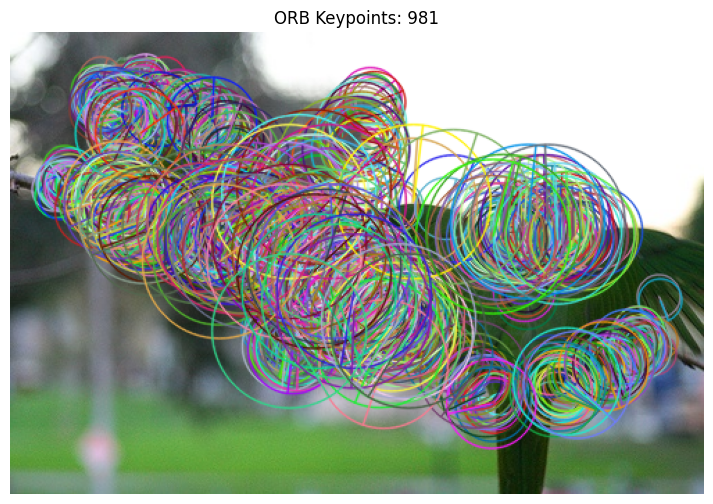

In [8]:
# Visualize the ORB keypoints detected on the clean sample image
image_with_keypoints = cv2.drawKeypoints(
    sample_image_np,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 6))
plt.imshow(image_with_keypoints)
plt.title(f"ORB Keypoints: {len(keypoints)}")
plt.axis("off")
plt.show()

In [9]:
# Run ORB on all clean images in the fixed experimental subset
orb = cv2.ORB_create(nfeatures=1500)

orb_clean_results = []

for index in selected_indices:
    image, _ = dataset[index]

    image_np = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    keypoints, descriptors = orb.detectAndCompute(gray, None)

    orb_clean_results.append({
        "dataset_index": index,
        "num_keypoints": len(keypoints),
        "has_descriptors": descriptors is not None,
        "descriptor_count": 0 if descriptors is None else descriptors.shape[0]
    })

orb_clean_df = pd.DataFrame(orb_clean_results)

print(f"Processed {len(orb_clean_df)} clean images")
display(orb_clean_df.head())

print(orb_clean_df["num_keypoints"].describe())

print(
    "Images reaching the maximum:",
    (orb_clean_df["num_keypoints"] == 1500).sum()
)

Processed 100 clean images


,dataset_index,num_keypoints,has_descriptors,descriptor_count
0,11,981,True,981
1,31,1449,True,1449
2,88,1460,True,1460
3,99,1414,True,1414
4,127,1500,True,1500


count     100.00000
mean     1336.09000
std       246.45663
min       344.00000
25%      1333.75000
50%      1441.00000
75%      1490.50000
max      1500.00000
Name: num_keypoints, dtype: float64
Images reaching the maximum: 18


In [10]:
# Save ORB clean-image baseline results
orb_results_path = RESULTS_DIR / "orb_clean_baseline.csv"

orb_clean_df.to_csv(orb_results_path, index=False)

print("ORB clean baseline saved to:")
print(orb_results_path)


ORB clean baseline saved to:
/content/results/orb_clean_baseline.csv


In [11]:
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)

In [12]:
# Load a pretrained DeepLabV3 model and its official preprocessing pipeline
segmentation_weights = DeepLabV3_ResNet50_Weights.DEFAULT

segmentation_model = deeplabv3_resnet50(
    weights=segmentation_weights
)

segmentation_model.eval()

segmentation_preprocess = segmentation_weights.transforms()

print("DeepLabV3 model loaded successfully")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 152MB/s]


DeepLabV3 model loaded successfully


In [13]:
# Run semantic segmentation on one clean sample image
sample_index = selected_indices[0]
sample_image, sample_mask = dataset[sample_index]

input_tensor = segmentation_preprocess(sample_image).unsqueeze(0)

with torch.no_grad():
    output = segmentation_model(input_tensor)["out"]

predicted_mask = output.argmax(dim=1).squeeze(0).cpu().numpy()

print("Input image size:", sample_image.size)
print("Predicted mask shape:", predicted_mask.shape)
print("Predicted class IDs:", np.unique(predicted_mask))


Input image size: (500, 333)
Predicted mask shape: (520, 780)
Predicted class IDs: [0 3]


In [14]:
# Resize the predicted mask back to the original ground-truth size
ground_truth_mask = np.array(sample_mask)

predicted_mask_resized = cv2.resize(
    predicted_mask.astype(np.uint8),
    sample_mask.size,  # PIL size is given as (width, height)
    interpolation=cv2.INTER_NEAREST
)

print("Ground-truth mask shape:", ground_truth_mask.shape)
print("Resized prediction shape:", predicted_mask_resized.shape)
print("Ground-truth class IDs:", np.unique(ground_truth_mask))
print("Predicted class IDs:", np.unique(predicted_mask_resized))

Ground-truth mask shape: (333, 500)
Resized prediction shape: (333, 500)
Ground-truth class IDs: [  0   3 255]
Predicted class IDs: [0 3]


In [15]:
# Compute IoU for the valid classes in one clean sample

valid_mask = ground_truth_mask != 255

gt_valid = ground_truth_mask[valid_mask]
pred_valid = predicted_mask_resized[valid_mask]

class_ids = np.union1d(
    np.unique(gt_valid),
    np.unique(pred_valid)
)

iou_per_class = {}

for class_id in class_ids:
    intersection = np.logical_and(
        gt_valid == class_id,
        pred_valid == class_id
    ).sum()

    union = np.logical_or(
        gt_valid == class_id,
        pred_valid == class_id
    ).sum()

    iou_per_class[int(class_id)] = (
        intersection / union if union > 0 else np.nan
    )

print("IoU per class:", iou_per_class)
print("Mean IoU:", np.nanmean(list(iou_per_class.values())))

IoU per class: {0: np.float64(0.9815051868599548), 3: np.float64(0.9429648047986465)}
Mean IoU: 0.9622349958293006


In [16]:
# Evaluate semantic segmentation on all clean images

segmentation_clean_results = []

for position, index in enumerate(selected_indices, start=1):
    image, ground_truth_pil = dataset[index]
    ground_truth = np.array(ground_truth_pil)

    input_tensor = segmentation_preprocess(image).unsqueeze(0)

    with torch.no_grad():
        output = segmentation_model(input_tensor)["out"]

    prediction = (
        output.argmax(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    prediction = cv2.resize(
        prediction,
        ground_truth_pil.size,
        interpolation=cv2.INTER_NEAREST
    )

    valid_pixels = ground_truth != 255
    gt_valid = ground_truth[valid_pixels]
    pred_valid = prediction[valid_pixels]

    class_ids = np.union1d(
        np.unique(gt_valid),
        np.unique(pred_valid)
    )

    class_ious = {}

    for class_id in class_ids:
        intersection = np.logical_and(
            gt_valid == class_id,
            pred_valid == class_id
        ).sum()

        union = np.logical_or(
            gt_valid == class_id,
            pred_valid == class_id
        ).sum()

        if union > 0:
            class_ious[int(class_id)] = intersection / union

    mean_iou_all_classes = np.mean(list(class_ious.values()))

    foreground_ious = [
        iou
        for class_id, iou in class_ious.items()
        if class_id != 0
    ]

    mean_iou_foreground = (
        np.mean(foreground_ious)
        if foreground_ious
        else np.nan
    )

    segmentation_clean_results.append({
        "dataset_index": index,
        "mean_iou_all_classes": mean_iou_all_classes,
        "mean_iou_foreground": mean_iou_foreground,
        "num_evaluated_classes": len(class_ious)
    })

    if position % 10 == 0:
        print(f"Processed {position}/{len(selected_indices)} images")

segmentation_clean_df = pd.DataFrame(segmentation_clean_results)

print("Finished evaluating all clean images")
display(segmentation_clean_df.head())

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images
Finished evaluating all clean images


,dataset_index,mean_iou_all_classes,mean_iou_foreground,num_evaluated_classes
0,11,0.962235,0.942965,2
1,31,0.328471,0.116096,4
2,88,0.985458,0.971731,2
3,99,0.653865,0.495152,3
4,127,0.503467,0.445977,8


In [17]:
# Summarize semantic-segmentation performance on all clean images

print("Mean IoU over all classes:")
print(segmentation_clean_df["mean_iou_all_classes"].describe())

print("\nMean IoU over foreground classes only:")
print(segmentation_clean_df["mean_iou_foreground"].describe())

print(
    "\nAverage clean-image mIoU including background:",
    segmentation_clean_df["mean_iou_all_classes"].mean()
)

print(
    "Average clean-image mIoU excluding background:",
    segmentation_clean_df["mean_iou_foreground"].mean()
)

Mean IoU over all classes:
count    100.000000
mean       0.768886
std        0.223562
min        0.248651
25%        0.607586
50%        0.871536
75%        0.971869
max        0.998647
Name: mean_iou_all_classes, dtype: float64

Mean IoU over foreground classes only:
count    100.000000
mean       0.700371
std        0.277896
min        0.000000
25%        0.474658
50%        0.821957
75%        0.955403
max        0.997637
Name: mean_iou_foreground, dtype: float64

Average clean-image mIoU including background: 0.7688864936054416
Average clean-image mIoU excluding background: 0.7003712973895208


In [18]:
# Save semantic-segmentation clean-image baseline results
segmentation_results_path = RESULTS_DIR / "segmentation_clean_baseline.csv"

segmentation_clean_df.to_csv(segmentation_results_path, index=False)

print("Segmentation clean baseline saved to:")
print(segmentation_results_path)


Segmentation clean baseline saved to:
/content/results/segmentation_clean_baseline.csv


## Object Detection Baseline

A pretrained YOLO model is evaluated on the clean images before applying distortions.

In [19]:
# Load a pretrained YOLO object-detection model
from ultralytics import YOLO

detection_model = YOLO("yolo11n.pt")

print("YOLO object-detection model loaded successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO object-detection model loaded successfully


In [20]:
# Run object detection on one clean sample image
sample_index = selected_indices[0]
sample_image, _ = dataset[sample_index]

detection_result = detection_model.predict(
    source=sample_image,
    conf=0.25,
    verbose=False
)[0]

num_detections = len(detection_result.boxes)

print(f"Dataset index: {sample_index}")
print(f"Number of detections: {num_detections}")

if num_detections > 0:
    detected_classes = detection_result.boxes.cls.cpu().numpy().astype(int)
    confidence_scores = detection_result.boxes.conf.cpu().numpy()

    print("Detected class IDs:", detected_classes)
    print("Confidence scores:", np.round(confidence_scores, 3))

Dataset index: 11
Number of detections: 3
Detected class IDs: [14 14 14]
Confidence scores: [       0.67       0.485       0.415]


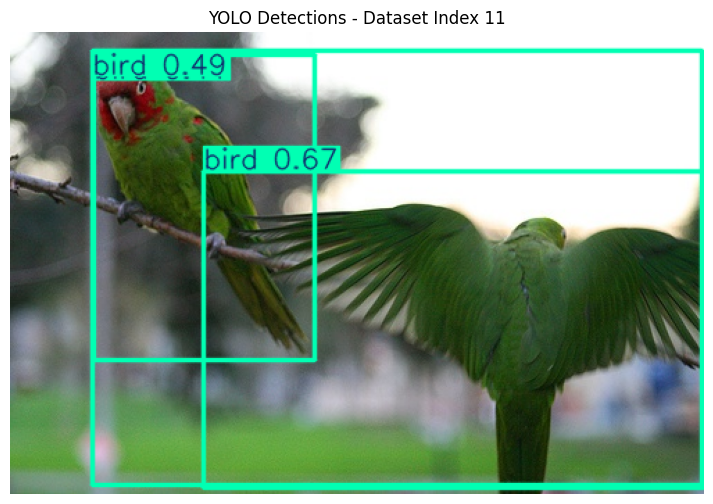

In [21]:
# Visualize YOLO detections on one clean sample image
annotated_image = detection_result.plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Detections - Dataset Index {sample_index}")
plt.axis("off")
plt.show()

In [22]:
# Locate object-detection XML annotations directly by image ID
from pathlib import Path

voc_root = DATA_DIR / "VOCdevkit" / "VOC2012"
annotations_dir = voc_root / "Annotations"

matched_annotation_paths = {}
missing_annotation_ids = []

for segmentation_index in selected_indices:
    image_id = Path(dataset.images[segmentation_index]).stem
    annotation_path = annotations_dir / f"{image_id}.xml"

    if annotation_path.exists():
        matched_annotation_paths[segmentation_index] = annotation_path
    else:
        missing_annotation_ids.append(image_id)

print(f"Images with XML annotations: {len(matched_annotation_paths)}")
print(f"Images without XML annotations: {len(missing_annotation_ids)}")
print("Missing image IDs:", missing_annotation_ids)

Images with XML annotations: 100
Images without XML annotations: 0
Missing image IDs: []


In [23]:
# Parse the ground-truth bounding boxes from one PASCAL VOC XML annotation
import xml.etree.ElementTree as ET

sample_index = selected_indices[0]
sample_image_id = Path(dataset.images[sample_index]).stem
sample_annotation_path = annotations_dir / f"{sample_image_id}.xml"

tree = ET.parse(sample_annotation_path)
root = tree.getroot()

ground_truth_objects = []

for obj in root.findall("object"):
    class_name = obj.find("name").text

    bbox = obj.find("bndbox")
    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    ground_truth_objects.append({
        "class_name": class_name,
        "bbox": [xmin, ymin, xmax, ymax]
    })

print(f"Image ID: {sample_image_id}")
print(f"Number of ground-truth objects: {len(ground_truth_objects)}")
print(ground_truth_objects)

Image ID: 2007_000363
Number of ground-truth objects: 2
[{'class_name': 'bird', 'bbox': [59, 15, 220, 239]}, {'class_name': 'bird', 'bbox': [161, 122, 500, 333]}]


In [24]:
# Compare YOLO predictions with ground-truth boxes for one clean image

def compute_box_iou(box_a, box_b):
    # Find the coordinates of the intersection rectangle
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)
    intersection_area = intersection_width * intersection_height

    # Compute the area of each bounding box
    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])

    union_area = area_a + area_b - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0


# Extract YOLO predictions: boxes, class IDs, and confidence scores
predicted_boxes = detection_result.boxes.xyxy.cpu().numpy()
predicted_class_ids = detection_result.boxes.cls.cpu().numpy().astype(int)
predicted_confidences = detection_result.boxes.conf.cpu().numpy()

yolo_class_names = detection_result.names

ground_truth_boxes = [
    obj["bbox"] for obj in ground_truth_objects
]

ground_truth_class_names = [
    obj["class_name"] for obj in ground_truth_objects
]

# Each matrix row represents a predicted box, and each column represents a ground-truth box
iou_matrix = np.zeros(
    (len(predicted_boxes), len(ground_truth_boxes)),
    dtype=float
)

for pred_idx, pred_box in enumerate(predicted_boxes):
    predicted_class_name = yolo_class_names[predicted_class_ids[pred_idx]]

    for gt_idx, gt_box in enumerate(ground_truth_boxes):
        # Compute IoU only when the predicted and ground-truth classes match
        if predicted_class_name == ground_truth_class_names[gt_idx]:
            iou_matrix[pred_idx, gt_idx] = compute_box_iou(
                pred_box,
                gt_box
            )

print("IoU matrix:")
print(np.round(iou_matrix, 3))

IoU matrix:
[[      0.104       0.836]
 [      0.262       0.493]
 [      0.973       0.068]]


In [25]:
# Match predictions to ground-truth boxes using a one-to-one IoU assignment
IOU_THRESHOLD = 0.5

candidate_matches = []

for pred_idx in range(iou_matrix.shape[0]):
    for gt_idx in range(iou_matrix.shape[1]):
        if iou_matrix[pred_idx, gt_idx] >= IOU_THRESHOLD:
            candidate_matches.append({
                "pred_idx": pred_idx,
                "gt_idx": gt_idx,
                "iou": iou_matrix[pred_idx, gt_idx]
            })

# Prioritize the highest-IoU matches
candidate_matches = sorted(
    candidate_matches,
    key=lambda match: match["iou"],
    reverse=True
)

matched_predictions = set()
matched_ground_truths = set()
valid_matches = []

for match in candidate_matches:
    pred_idx = match["pred_idx"]
    gt_idx = match["gt_idx"]

    # Each prediction and ground-truth object may be matched only once
    if (
        pred_idx not in matched_predictions
        and gt_idx not in matched_ground_truths
    ):
        valid_matches.append(match)
        matched_predictions.add(pred_idx)
        matched_ground_truths.add(gt_idx)

true_positives = len(valid_matches)
false_positives = len(predicted_boxes) - true_positives
false_negatives = len(ground_truth_boxes) - true_positives

precision = (
    true_positives / (true_positives + false_positives)
    if true_positives + false_positives > 0
    else 0.0
)

recall = (
    true_positives / (true_positives + false_negatives)
    if true_positives + false_negatives > 0
    else 0.0
)

mean_matched_iou = (
    np.mean([match["iou"] for match in valid_matches])
    if valid_matches
    else 0.0
)

print("Valid matches:", valid_matches)
print("True positives:", true_positives)
print("False positives:", false_positives)
print("False negatives:", false_negatives)
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("Mean matched IoU:", round(mean_matched_iou, 3))

Valid matches: [{'pred_idx': 2, 'gt_idx': 0, 'iou': np.float64(0.9729354977607727)}, {'pred_idx': 0, 'gt_idx': 1, 'iou': np.float64(0.8355823159217834)}]
True positives: 2
False positives: 1
False negatives: 0
Precision: 0.667
Recall: 1.0
Mean matched IoU: 0.904


In [26]:
# Normalize YOLO class names to the corresponding PASCAL VOC class names
YOLO_TO_VOC_CLASS_NAMES = {
    "airplane": "aeroplane",
    "motorcycle": "motorbike",
    "couch": "sofa",
    "tv": "tvmonitor",
    "potted plant": "pottedplant",
    "dining table": "diningtable"
}


def normalize_to_voc_class_name(class_name):
    return YOLO_TO_VOC_CLASS_NAMES.get(class_name, class_name)

In [27]:
# Evaluate YOLO object detection on all clean images

detection_clean_results = []

for position, index in enumerate(selected_indices, start=1):
    image, _ = dataset[index]
    image_id = Path(dataset.images[index]).stem
    annotation_path = annotations_dir / f"{image_id}.xml"

    # Parse ground-truth objects from XML
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    ground_truth_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        ground_truth_objects.append({
            "class_name": class_name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    # Run YOLO on the clean image
    result = detection_model.predict(
        source=image,
        conf=0.25,
        verbose=False
    )[0]

    predicted_boxes = result.boxes.xyxy.cpu().numpy()
    predicted_class_ids = result.boxes.cls.cpu().numpy().astype(int)
    predicted_class_names = [
        normalize_to_voc_class_name(result.names[class_id])
        for class_id in predicted_class_ids
    ]

    ground_truth_boxes = [
        obj["bbox"] for obj in ground_truth_objects
    ]

    ground_truth_class_names = [
        obj["class_name"] for obj in ground_truth_objects
    ]

    # Build the IoU matrix only for matching classes
    iou_matrix = np.zeros(
        (len(predicted_boxes), len(ground_truth_boxes)),
        dtype=float
    )

    for pred_idx, pred_box in enumerate(predicted_boxes):
        for gt_idx, gt_box in enumerate(ground_truth_boxes):
            if predicted_class_names[pred_idx] == ground_truth_class_names[gt_idx]:
                iou_matrix[pred_idx, gt_idx] = compute_box_iou(
                    pred_box,
                    gt_box
                )

    # Create one-to-one matches above the IoU threshold
    candidate_matches = []

    for pred_idx in range(iou_matrix.shape[0]):
        for gt_idx in range(iou_matrix.shape[1]):
            if iou_matrix[pred_idx, gt_idx] >= IOU_THRESHOLD:
                candidate_matches.append({
                    "pred_idx": pred_idx,
                    "gt_idx": gt_idx,
                    "iou": iou_matrix[pred_idx, gt_idx]
                })

    candidate_matches = sorted(
        candidate_matches,
        key=lambda match: match["iou"],
        reverse=True
    )

    matched_predictions = set()
    matched_ground_truths = set()
    valid_matches = []

    for match in candidate_matches:
        pred_idx = match["pred_idx"]
        gt_idx = match["gt_idx"]

        if (
            pred_idx not in matched_predictions
            and gt_idx not in matched_ground_truths
        ):
            valid_matches.append(match)
            matched_predictions.add(pred_idx)
            matched_ground_truths.add(gt_idx)

    true_positives = len(valid_matches)
    false_positives = len(predicted_boxes) - true_positives
    false_negatives = len(ground_truth_boxes) - true_positives

    precision = (
        true_positives / (true_positives + false_positives)
        if true_positives + false_positives > 0
        else 0.0
    )

    recall = (
        true_positives / (true_positives + false_negatives)
        if true_positives + false_negatives > 0
        else 0.0
    )

    mean_matched_iou = (
        np.mean([match["iou"] for match in valid_matches])
        if valid_matches
        else 0.0
    )

    detection_clean_results.append({
        "dataset_index": index,
        "image_id": image_id,
        "num_ground_truth_objects": len(ground_truth_boxes),
        "num_predictions": len(predicted_boxes),
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": precision,
        "recall": recall,
        "mean_matched_iou": mean_matched_iou
    })

    if position % 10 == 0:
        print(f"Processed {position}/{len(selected_indices)} images")

detection_clean_df = pd.DataFrame(detection_clean_results)

print("Finished evaluating object detection on all clean images")
display(detection_clean_df.head())

Processed 10/100 images
Processed 20/100 images
Processed 30/100 images
Processed 40/100 images
Processed 50/100 images
Processed 60/100 images
Processed 70/100 images
Processed 80/100 images
Processed 90/100 images
Processed 100/100 images
Finished evaluating object detection on all clean images


,dataset_index,image_id,num_ground_truth_objects,num_predictions,true_positives,false_positives,false_negatives,precision,recall,mean_matched_iou
0,11,2007_000363,2,3,2,1,0,0.666667,1.000000,0.904259
1,31,2007_000904,3,4,1,3,2,0.250000,0.333333,0.803344
2,88,2007_002895,2,5,2,3,0,0.400000,1.000000,0.733853
3,99,2007_003191,1,1,1,0,0,1.000000,1.000000,0.978158
4,127,2007_004166,8,10,6,4,2,0.600000,0.750000,0.901281


In [28]:
# Summarize YOLO object-detection performance on all clean images

print("Per-image precision:")
print(detection_clean_df["precision"].describe())

print("\nPer-image recall:")
print(detection_clean_df["recall"].describe())

print("\nMean matched IoU:")
print(detection_clean_df["mean_matched_iou"].describe())

total_tp = detection_clean_df["true_positives"].sum()
total_fp = detection_clean_df["false_positives"].sum()
total_fn = detection_clean_df["false_negatives"].sum()

global_precision = (
    total_tp / (total_tp + total_fp)
    if total_tp + total_fp > 0
    else 0.0
)

global_recall = (
    total_tp / (total_tp + total_fn)
    if total_tp + total_fn > 0
    else 0.0
)

global_f1 = (
    2 * global_precision * global_recall
    / (global_precision + global_recall)
    if global_precision + global_recall > 0
    else 0.0
)

print("\nGlobal object-detection results:")
print("Total true positives:", total_tp)
print("Total false positives:", total_fp)
print("Total false negatives:", total_fn)
print("Global precision:", round(global_precision, 3))
print("Global recall:", round(global_recall, 3))
print("Global F1:", round(global_f1, 3))

Per-image precision:
count    100.000000
mean       0.713466
std        0.281467
min        0.000000
25%        0.500000
50%        0.732143
75%        1.000000
max        1.000000
Name: precision, dtype: float64

Per-image recall:
count    100.000000
mean       0.854403
std        0.231838
min        0.000000
25%        0.750000
50%        1.000000
75%        1.000000
max        1.000000
Name: recall, dtype: float64

Mean matched IoU:
count    100.000000
mean       0.878823
std        0.120495
min        0.000000
25%        0.835541
50%        0.904668
75%        0.955368
max        0.991857
Name: mean_matched_iou, dtype: float64

Global object-detection results:
Total true positives: 220
Total false positives: 160
Total false negatives: 72
Global precision: 0.579
Global recall: 0.753
Global F1: 0.655


In [29]:
# Save YOLO clean-image baseline results
detection_results_path = RESULTS_DIR / "detection_clean_baseline.csv"

detection_clean_df.to_csv(detection_results_path, index=False)

print("Object-detection clean baseline saved to:")
print(detection_results_path)


Object-detection clean baseline saved to:
/content/results/detection_clean_baseline.csv
